# Multi-Algorithm PCB Defect Inspection: Authoritative Validation Benchmark

This notebook presents the head-to-head validation comparison across all four defect-inspection algorithms on the 139-image validation split. All candidates use the predetermined shared preprocessing pipeline (3×3 Gaussian denoising followed by CLAHE with clip limit 2.0 and tile grid 8×8). Algorithm-specific settings are compared by aggregate F1-score at IoU 0.50; the highest-F1 configuration for each algorithm is frozen for testing.

1. **Otsu's Global Thresholding** (Intensity difference + morphology)
2. **Template Matching** (Multi-scale normalized cross-correlation)
3. **Canny Edge Detection** (Gradient difference + closing)
4. **ORB Feature Matching** (Keypoint alignment & spatial descriptor displacement)

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

PROJECT_ROOT = Path.cwd().parent.parent if Path.cwd().name == 'validation' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Smart auto-run fallback: auto-compute benchmark if outputs/metrics CSV is missing
res_csv = PROJECT_ROOT / 'outputs' / 'metrics' / 'essential_validation_comparison.csv'
if not res_csv.exists():
    print('⚠️ Validation metrics CSV not found. Auto-running validation benchmark on 139 validation images...')
    from scripts.evaluation.run_essential_validation import main as run_benchmark
    run_benchmark()
    print('✅ Benchmark successfully generated!')

df = pd.read_csv(res_csv)
df['description'] = df['description'].replace({
    'Raw Otsu difference without denoising or dilation': 'Validation reference: shared preprocessing; no Otsu-specific median blur, dilation, or area filter',
    'Raw edge difference (low=50, high=150, no morph)': 'Validation reference: shared preprocessing + low=50, high=150; no Canny-specific morphology',
    'Raw 64x64 baseline without contour merging': 'Validation reference: shared preprocessing + 64x64 window; no contour grouping',
    'Raw discrete keypoint boxes (Hamming=60, R=35, Merge=False)': 'Validation reference: shared preprocessing + discrete keypoint boxes (Hamming=60, R=35, Merge=False)',
})
assert len(df) == 16 and set(df['algorithm']) == {'Otsu', 'Template Matching', 'Canny', 'ORB'}
display(df)


,algorithm,combination_id,description,parameter_config,true_positives,false_positives,false_negatives,precision,recall,f1_score,mean_runtime_ms
0,Template Matching,TM-Baseline,Validation reference: shared preprocessing + 6...,"{""method"":""TM_CCOEFF_NORMED"",""block_size"":[64,...",32,53,549,0.376471,0.055077,0.096096,232.194442
1,Template Matching,TM-Macro-96x96,Macro 96x96 sliding window with findContours,"{""method"":""TM_CCOEFF_NORMED"",""block_size"":[96,...",3,21,578,0.125000,0.005164,0.009917,239.519830
2,Template Matching,TM-Enhanced-32x32-Thresh55,"Tight 32x32 window (thresh=0.55, high precision)","{""method"":""TM_CCOEFF_NORMED"",""block_size"":[32,...",239,247,342,0.491770,0.411360,0.447985,399.062253
3,Template Matching,TM-Best-32x32-Thresh65,"Optimal 32x32 window (thresh=0.65, high recall)","{""method"":""TM_CCOEFF_NORMED"",""block_size"":[32,...",319,517,262,0.381579,0.549053,0.450247,567.126324
4,Otsu,Otsu-Baseline,Validation reference: shared preprocessing; no...,"{""method"":""THRESH_BINARY+THRESH_OTSU"",""blur_ks...",146,13497890,435,0.000011,0.251291,0.000022,964.117852
5,Otsu,Otsu-Filtered-NoDilate,"Median blur + area filter (no dilation, micro ...","{""method"":""THRESH_BINARY+THRESH_OTSU"",""blur_ks...",1,4700,580,0.000213,0.001721,0.000379,97.886954
6,Otsu,Otsu-Dilated-25,Median blur + dilation 25 + min_area 150,"{""method"":""THRESH_BINARY+THRESH_OTSU"",""blur_ks...",403,164,178,0.710758,0.693632,0.702091,63.991200
7,Otsu,Otsu-Best-Dilated-35,Optimal median blur + dilation 35 + min_area 150,"{""method"":""THRESH_BINARY+THRESH_OTSU"",""blur_ks...",479,81,102,0.855357,0.824441,0.839614,54.877985
8,Canny,Canny-Baseline,Validation reference: shared preprocessing + l...,"{""low_threshold"":50,""high_threshold"":150,""aper...",10,4253505,571,0.000002,0.017212,0.000005,376.941131
9,Canny,Canny-Closed-Area150,Edge difference with closing 5 + min_area 150,"{""low_threshold"":50,""high_threshold"":150,""aper...",69,6880,512,0.009929,0.118761,0.018327,233.082398


## 1. Best-in-Class Comparison Table (Top-1 Per Algorithm)

In [2]:
best_per_algo = df.sort_values('f1_score', ascending=False).groupby('algorithm', as_index=False).first()
best_per_algo = best_per_algo.sort_values('f1_score', ascending=False)
with open(PROJECT_ROOT / 'configs' / 'frozen_parameters.yaml') as handle:
    frozen = yaml.safe_load(handle)
expected_winners = {name: details['combination_id'] for name, details in frozen['selection']['winners'].items()}
actual_winners = dict(zip(best_per_algo['algorithm'].map({'Otsu': 'otsu', 'Template Matching': 'template_matching', 'Canny': 'canny', 'ORB': 'orb'}), best_per_algo['combination_id']))
assert actual_winners == expected_winners
display(best_per_algo[['algorithm', 'combination_id', 'description', 'precision', 'recall', 'f1_score', 'mean_runtime_ms']])


,algorithm,combination_id,description,precision,recall,f1_score,mean_runtime_ms
2,Otsu,Otsu-Best-Dilated-35,Optimal median blur + dilation 35 + min_area 150,0.855357,0.824441,0.839614,54.877985
3,Template Matching,TM-Best-32x32-Thresh65,"Optimal 32x32 window (thresh=0.65, high recall)",0.381579,0.549053,0.450247,567.126324
0,Canny,Canny-Best-Area300,"Optimal low=50, high=150 with closing 5 + min_...",0.034254,0.115318,0.052818,228.628376
1,ORB,ORB-Best-Area300,Optimal compact clustering with noise filter (...,0.003115,0.122203,0.006075,556.631940


## 2. Comparative Benchmark Charts: F1-Score & Latency

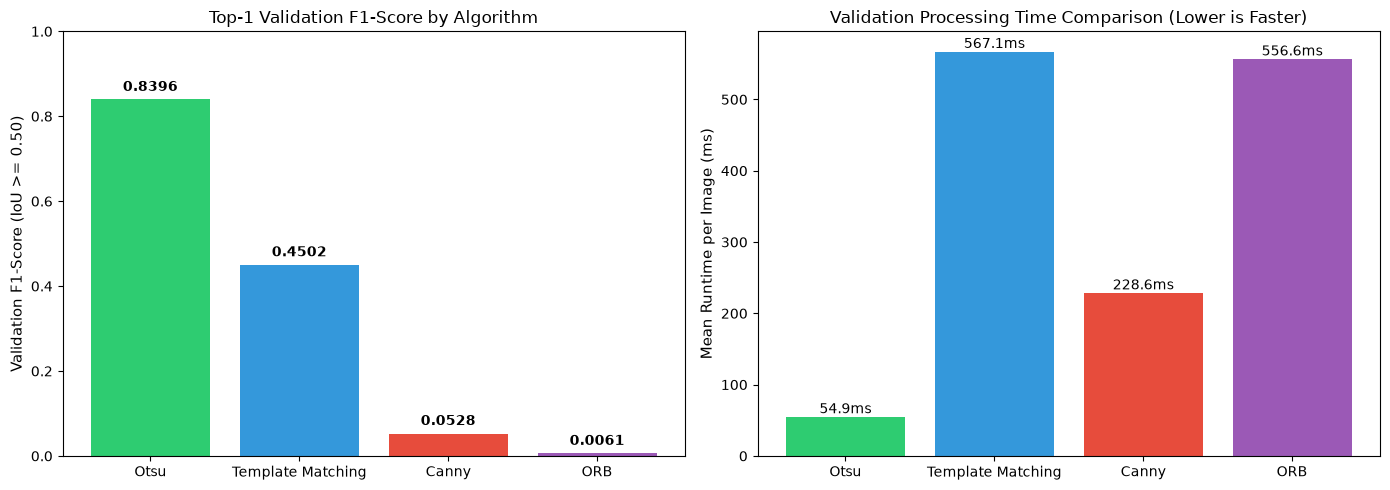

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2ecc71', '#3498db', '#e74c3c', '#9b59b6']
ax1.bar(best_per_algo['algorithm'], best_per_algo['f1_score'], color=colors)
ax1.set_ylabel('Validation F1-Score (IoU >= 0.50)', fontsize=11)
ax1.set_title('Top-1 Validation F1-Score by Algorithm', fontsize=12)
ax1.set_ylim(0, 1.0)
for i, v in enumerate(best_per_algo['f1_score']):
    ax1.text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

ax2.bar(best_per_algo['algorithm'], best_per_algo['mean_runtime_ms'], color=colors)
ax2.set_ylabel('Mean Runtime per Image (ms)', fontsize=11)
ax2.set_title('Validation Processing Time Comparison (Lower is Faster)', fontsize=12)
for i, v in enumerate(best_per_algo['mean_runtime_ms']):
    ax2.text(i, v + 5, f'{v:.1f}ms', ha='center')

plt.tight_layout()
plt.show()
